[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/fast_track/20_shipping_scheduling_and_deployment.ipynb)

# 📓 Notebook 20 (fast track) — Shipping: Scheduling & Deployment

> **Module:** Production & Deployment · **Estimated time:** 65–80 min · **Difficulty:** Intermediate

You've packaged your code into a real project (fast-track NB 13). Now you have to **ship** it — run it unattended, night after night, on machines that aren't your laptop, without it quietly rotting. That's the part the fast track otherwise skips, and it's what this notebook condenses.

It pulls together two canonical chapters:

- **Scheduling & orchestration** — the canonical [`13_production/46_scheduling_orchestration.ipynb`](../13_production/46_scheduling_orchestration.ipynb).
- **The CI/CD & Docker mini-book** — [`14_cicd/`](../14_cicd/), whose hands-on labs `lab01_docker_and_compose.ipynb` and `lab02_ci_pipeline_github_actions.ipynb` build real containers and pipelines. Here we keep the *ideas* and **simulate the machinery in pure Python** — no Docker daemon, no cloud, no YAML runner, 100% offline.

> 🧭 **Mental model — shipping is three promises.** A shipped system keeps three promises: **(1) it runs on a schedule you trust** (the job fires when it should, and re-running it never does damage), **(2) it's packaged so it runs the same everywhere** (the same bytes on your laptop, in CI, and in production), and **(3) it rebuilds and re-tests itself automatically on every change** (nothing reaches production untested). We'll build a tiny working model of each — a cron matcher + scheduler loop, a Dockerfile → layer-cache simulator, and a jobs-with-`needs` CI graph — small enough to read in one sitting, faithful enough to teach the real thing.

> 🏎️ **You're on the fast track.** This notebook *condenses* the canonical scheduling notebook and the CI/CD mini-book listed above. The deepest Stretch exercises (A and B) and the 🎁 Bonus mini-project are trimmed; the harder Stretch C and D are kept. Open the canonical material when you want to run real Docker and a real GitHub Actions pipeline.

## 🎯 Learning objectives

By the end of this notebook you can:

1. Turn a plain function into a **scheduled job** and fire it from a tiny in-process scheduler.
2. Read and match five-field **cron expressions** with a standard-library `matches(cron_expr, when)` checker.
3. Make a job **idempotent** so retries, backfills, and double-fires are safe.
4. Add **retries with exponential backoff** using a decorator.
5. Read a **Dockerfile** as a list of instructions and hash them into cacheable **layers**.
6. Predict **which layers rebuild** after a change — and order a Dockerfile *requirements first, code last*.
7. Model a **CI workflow** as jobs-with-`needs` and topologically sort it into parallel **execution waves**.
8. "Run" a CI pipeline (a lint + a `pytest`) locally and collect the results into a table.

## ✅ Prerequisites

Fast-track **NB 13** (notebook → project): you should be comfortable with a `src/` package, `pyproject.toml`, and `pytest`. Everything here builds on that project as the thing we schedule, containerise, and test.

---

## Part 1 · Scheduling — *run it on a schedule you trust*

Promise #1. Your `costkit` report doesn't run itself — something has to wake up at 03:00 and call it. In production that "something" is cron, systemd timers, Airflow, or a cloud scheduler. Strip them all down and you find the same three parts: **a clock**, **a rule for when to fire**, and **a job that's safe to fire**. We'll build all three in pure Python.

### 1. A task worth scheduling

A scheduled job is just a function. Ours pretends to build a daily report and write it to disk. We use a throwaway temp directory so the notebook leaves nothing behind.

In [1]:
import datetime as dt
import tempfile
from pathlib import Path

WORK = Path(tempfile.mkdtemp(prefix="ship20_"))   # scratch space, auto-unique

def build_report(run_date):
    '''Pretend to build the report for one day. Returns the output path.'''
    out = WORK / f"report_{run_date:%Y-%m-%d}.txt"
    out.write_text(f"daily report for {run_date:%Y-%m-%d}\n")
    return out

path = build_report(dt.datetime(2026, 3, 2))
print("wrote:", path.name, "->", path.read_text().strip())

wrote: report_2026-03-02.txt -> daily report for 2026-03-02


### 2. A cron-tick checker: `matches(cron_expr, when)`

Cron is the lingua franca of scheduling. A cron expression is **five fields** — `minute hour day-of-month month day-of-week` — and a job fires on any minute where *all five* fields match the clock. Each field is `*` (any), a number, a list `1,2,3`, a range `1-5`, or a step `*/15`.

We won't run a daemon; we'll write the one function every scheduler needs — *does this expression match this moment?* — and drive it with a clock we control.

> ⚠️ **The #1 cron gotcha — day-of-week numbering.** Cron's day-of-week is `0–6` with **Sunday = 0** (so Monday–Friday is `1-5`). Python's `datetime.weekday()` uses the *other* convention — **Monday = 0** — so we translate with `cron_dow = (when.weekday() + 1) % 7`. Mixing the two up is the most common bug in this whole domain: a schedule that's silently off by one day can hide for weeks.

In [2]:
def _field_matches(field, value):
    '''True if a single cron field (*, n, a-b, a,b,c, or */k) matches value.'''
    for part in field.split(","):
        if part == "*":
            return True
        if part.startswith("*/"):
            if value % int(part[2:]) == 0:
                return True
        elif "-" in part:
            lo, hi = (int(x) for x in part.split("-"))
            if lo <= value <= hi:
                return True
        elif int(part) == value:
            return True
    return False

def matches(cron_expr, when):
    '''True if the 5-field cron_expr fires at datetime `when`.'''
    minute, hour, dom, month, dow = cron_expr.split()
    cron_dow = (when.weekday() + 1) % 7          # Python Mon=0 -> cron Sun=0
    return (
        _field_matches(minute, when.minute)
        and _field_matches(hour, when.hour)
        and _field_matches(dom, when.day)
        and _field_matches(month, when.month)
        and _field_matches(dow, cron_dow)
    )

nine_am = dt.datetime(2026, 3, 2, 9, 0)          # a Monday, 09:00
print('"0 9 * * *"    @ Mon 09:00 ->', matches("0 9 * * *", nine_am))
print('"0 9 * * *"    @ Mon 09:30 ->', matches("0 9 * * *", nine_am.replace(minute=30)))
print('"*/15 * * * *" @ Mon 09:30 ->', matches("*/15 * * * *", nine_am.replace(minute=30)))
print('"0 * * * 1-5"  @ Mon 09:00 ->', matches("0 * * * 1-5", nine_am), "(Mon–Fri)")

"0 9 * * *"    @ Mon 09:00 -> True
"0 9 * * *"    @ Mon 09:30 -> False
"*/15 * * * *" @ Mon 09:30 -> True
"0 * * * 1-5"  @ Mon 09:00 -> True (Mon–Fri)


### 3. `TinyScheduler` — the loop

A real scheduler wakes once a minute, asks `matches(...)` for every registered job, and runs the ones that fire. Instead of sleeping through real time, we feed the scheduler an explicit list of **ticks** (simulated minutes) so the demo is instant and deterministic — the exact trick the canonical notebook and CI use to test schedules.

In [3]:
class TinyScheduler:
    '''Register (cron, job) pairs; fire each job on every tick it matches.'''
    def __init__(self):
        self.jobs = []

    def every(self, cron_expr, func, name=None):
        self.jobs.append((cron_expr, func, name or func.__name__))
        return self                                    # chainable

    def run_ticks(self, ticks):
        log = []
        for now in ticks:                              # the "clock", one entry per minute
            for cron_expr, func, name in self.jobs:
                if matches(cron_expr, now):
                    func(now)
                    log.append((now, name))
        return log

fired = []
sched = (
    TinyScheduler()
    .every("0 9 * * *",   lambda now: fired.append(("report", now)),      "daily_report")
    .every("0 */6 * * *", lambda now: fired.append(("healthcheck", now)), "healthcheck")
)

# Simulate two days, one tick per hour (48 ticks).
start = dt.datetime(2026, 3, 2, 0, 0)                  # Monday 00:00
ticks = [start + dt.timedelta(hours=h) for h in range(48)]
log = sched.run_ticks(ticks)

import pandas as pd
log_df = pd.DataFrame(log, columns=["fired_at", "job"])
print(f"{len(log)} firings across {len(ticks)} hourly ticks")
log_df

10 firings across 48 hourly ticks


,fired_at,job
0,2026-03-02 00:00:00,healthcheck
1,2026-03-02 06:00:00,healthcheck
2,2026-03-02 09:00:00,daily_report
3,2026-03-02 12:00:00,healthcheck
4,2026-03-02 18:00:00,healthcheck
5,2026-03-03 00:00:00,healthcheck
6,2026-03-03 06:00:00,healthcheck
7,2026-03-03 09:00:00,daily_report
8,2026-03-03 12:00:00,healthcheck
9,2026-03-03 18:00:00,healthcheck


> 🔬 **Why a matcher, not a `sleep` loop?** Separating *"when should this fire?"* (`matches`) from *"advance the clock"* (`run_ticks`) is what makes a scheduler **testable**. You can replay a whole year of ticks in milliseconds and assert the job fired exactly when it should — no waiting, no flakiness. Every serious scheduler is built this way.

### 4. Idempotency — safe to run twice

Here is the rule that separates a hobby script from a production job:

> **A scheduled job will run more than once.** Retries, manual re-runs, backfills, two workers grabbing the same tick, a clock that skips back an hour on DST — all of them fire your job again. So a job must be **idempotent**: running it twice does the same thing as running it once.

The cheapest way to get there is a guard: check whether the work is already done before doing it again.

In [4]:
def idempotent_report(run_date):
    '''Build the report only if it isn't already there; safe to call repeatedly.'''
    out = WORK / f"report_{run_date:%Y-%m-%d}.txt"
    if out.exists():
        return out, "skipped (already done)"
    out.write_text(f"daily report for {run_date:%Y-%m-%d}\n")
    return out, "created"

day = dt.datetime(2026, 4, 1)
print("run 1:", idempotent_report(day)[1])   # created
print("run 2:", idempotent_report(day)[1])   # skipped — no duplicate, no harm
print("run 3:", idempotent_report(day)[1])   # skipped

run 1: created
run 2: skipped (already done)
run 3: skipped (already done)


> ⚠️ **Non-idempotent jobs are a data-integrity bug waiting to happen.** A job that appends a row, sends an email, or charges a card on *every* run will double-charge the day a retry fires. The fix is a natural key (here, the date) plus an "already done?" check — or an upsert/`INSERT ... ON CONFLICT` at the database. Design for the second run *first*.

### 5. Retries with backoff

Networks blink, databases hiccup, an API rate-limits you. The right response to a *transient* failure isn't to crash — it's to wait a moment and try again, waiting a little longer each time (**exponential backoff**) so you don't hammer a service that's already struggling. A decorator wraps this around any function without touching its body.

In [5]:
import functools
import time

def retry(attempts=3, base_delay=0.01, backoff=2.0):
    '''Retry the wrapped call on any exception, backing off between tries.'''
    def decorator(func):
        @functools.wraps(func)
        def wrapper(*args, **kwargs):
            delay = base_delay
            for attempt in range(1, attempts + 1):
                try:
                    return func(*args, **kwargs)
                except Exception as exc:
                    if attempt == attempts:
                        raise                          # give up: re-raise the last error
                    print(f"  attempt {attempt} failed ({exc}); retrying in {delay:.2f}s")
                    time.sleep(delay)
                    delay *= backoff
        return wrapper
    return decorator

calls = {"n": 0}

@retry(attempts=5, base_delay=0.01)
def flaky_fetch():
    calls["n"] += 1
    if calls["n"] < 3:
        raise ConnectionError(f"transient error on call {calls['n']}")
    return "payload"

print("result:", flaky_fetch(), "after", calls["n"], "attempts")

  attempt 1 failed (transient error on call 1); retrying in 0.01s
  attempt 2 failed (transient error on call 2); retrying in 0.02s


result: payload after 3 attempts


> ⚠️ **Backoff needs a ceiling — and jitter.** Pure exponential backoff can grow to hours, and if a thousand clients all retry on the same doubling schedule they reconverge into a *thundering herd* that knocks the service over again. Production retries cap the delay (`min(delay, 60)`) and add random **jitter** so clients spread out. And only ever retry **transient** errors — retrying a `400 Bad Request` just fails five times instead of once.

---

### ✋ Quick exercise (~2 min) — Write a cron expression

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Write the five-field cron expression for **"every weekday at 08:30"** and verify it with `matches()`. Remember the field order — `minute hour day-of-month month day-of-week` — and real cron's weekday numbering: **Sunday = 0 … Saturday = 6**, so Monday–Friday is `1-5`.

In [6]:
# ✍️ Your turn 👇
# Fields:  minute  hour  day-of-month  month  day-of-week   (cron weekday Sun=0 … Sat=6)
expr = "* * * * *"     # <- replace with "every weekday at 08:30"
# Test it (uncomment): 2026-03-02 is a Monday, 2026-03-07 a Saturday.
# print("Mon 08:30 ->", matches(expr, dt.datetime(2026, 3, 2, 8, 30)))   # want True
# print("Sat 08:30 ->", matches(expr, dt.datetime(2026, 3, 7, 8, 30)))   # want False

<details>
<summary>✅ <b>Solution</b></summary>

```python
expr = "30 8 * * 1-5"   # minute=30, hour=8, any day, any month, Mon–Fri (cron 1-5)
assert matches(expr, dt.datetime(2026, 3, 2, 8, 30))       # Monday 08:30  -> fires
assert not matches(expr, dt.datetime(2026, 3, 7, 8, 30))   # Saturday      -> no
assert not matches(expr, dt.datetime(2026, 3, 2, 9, 30))   # wrong minute  -> no
assert not matches(expr, dt.datetime(2026, 3, 2, 8, 0))    # wrong minute  -> no
print("cron ok:", expr)
```

The minute (`30`) and hour (`8`) pin the time; `* *` leaves the date open; `1-5` is a **range** covering Monday through Friday (cron counts Sunday as 0). Read cron left-to-right and it says exactly that.
</details>

## Part 2 · Containers, simulated — *package it so it runs the same everywhere*

Promise #2. "Works on my machine" is where deployments go to die. A **container** packages your code *with* its Python version, its OS libraries, and its dependencies into one image that runs identically on your laptop, in CI, and in production. You describe the image in a **Dockerfile**, and Docker builds it into stacked, cached **layers**.

We won't install Docker. We'll do what `lab01_docker_and_compose.ipynb` does under the hood: parse a Dockerfile into instructions, hash each into a layer, and replay the **build cache** to see exactly what rebuilds when — because that cache is where 90% of real-world build-time pain lives.

### 6. A Dockerfile is a list of instructions

Each line is an **instruction** (`FROM`, `WORKDIR`, `COPY`, `RUN`, `CMD`, …). Parsing one is a five-line loop.

In [7]:
DOCKERFILE = '''
# syntax reminder: INSTRUCTION arguments
FROM python:3.11-slim
WORKDIR /app
COPY requirements.txt .
RUN pip install -r requirements.txt
COPY src/ ./src/
CMD ["python", "-m", "costkit", "1000", "500"]
'''

def parse_dockerfile(text):
    '''Return [(verb, args), ...], skipping blanks and comments.'''
    instructions = []
    for line in text.strip().splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        verb, _, args = line.partition(" ")
        instructions.append((verb, args.strip()))
    return instructions

INSTRUCTIONS = parse_dockerfile(DOCKERFILE)
for verb, args in INSTRUCTIONS:
    print(f"{verb:8} {args}")

FROM     python:3.11-slim
WORKDIR  /app
COPY     requirements.txt .
RUN      pip install -r requirements.txt
COPY     src/ ./src/
CMD      ["python", "-m", "costkit", "1000", "500"]


### 7. Instructions → layers (hashing)

Docker turns each instruction into a **layer** — a cached filesystem diff. The key idea: a layer can be **reused from cache** only if nothing it depends on changed. For a `COPY`, that includes the *content of the files it copies in*; for a `RUN`, the command text.

We give each layer a short hash of its instruction plus, for a `COPY`, a hash of the file contents it pulls from a **build context** (a dict of `path -> content`).

> 🔬 **One honest simplification.** Real Docker chains each layer's hash onto its parent's, so a change automatically **cascades** to every later layer. We hash layers *independently* (instruction + copied content only) and apply the cascade as an **explicit rule** in the next cell. Same result — but the rule is now visible in code, which is exactly the rule the "Debug me" exercise later forgets.

In [8]:
import hashlib

def _sha(text):
    return hashlib.sha256(text.encode()).hexdigest()[:12]

def _content_hash(spec, context):
    '''Hash of the build-context files a COPY pulls in (spec is its first arg).'''
    if spec == ".":
        keys = sorted(context)                         # COPY . .  -> everything
    else:
        prefix = spec.rstrip("/") + "/"
        keys = sorted(p for p in context if p == spec or p.startswith(prefix))
    return _sha("|".join(f"{k}={context[k]}" for k in keys))

def build_layers(instructions, context):
    '''Return [{'instruction', 'hash'}, ...], one entry per layer.'''
    layers = []
    for verb, args in instructions:
        material = f"{verb} {args}"
        if verb == "COPY":
            material += "::" + _content_hash(args.split()[0], context)
        layers.append({"instruction": f"{verb} {args}", "hash": _sha(material)})
    return layers

# Build context: the files the Dockerfile copies in.
context = {
    "requirements.txt": "pandas==3.0\n",
    "src/app.py": "print('v1')\n",
}
base_layers = build_layers(INSTRUCTIONS, context)
for i, layer in enumerate(base_layers, 1):
    print(f"layer {i}: {layer['hash']}  {layer['instruction']}")

layer 1: 81e1b9ce43d2  FROM python:3.11-slim
layer 2: d8736a23cc33  WORKDIR /app
layer 3: d34284624f2c  COPY requirements.txt .
layer 4: 8cf4181cb8de  RUN pip install -r requirements.txt
layer 5: 3ae844dc6633  COPY src/ ./src/
layer 6: a271befac9db  CMD ["python", "-m", "costkit", "1000", "500"]


### 8. The build cache — what rebuilds?

Now the cache rule, stated once: **walk the layers top to bottom; a layer is a cache hit only if its hash is unchanged *and every layer before it was a hit too*. The moment one layer changes, it and everything after it must rebuild.** That latch — once you start rebuilding you don't stop — is the whole game.

In [9]:
def replay_cache(old_layers, new_layers):
    '''Compare a fresh build to a cached one; mark each layer hit or REBUILD.'''
    rows, rebuilding = [], False
    for i, layer in enumerate(new_layers):
        changed = i >= len(old_layers) or layer["hash"] != old_layers[i]["hash"]
        if changed:
            rebuilding = True                          # the latch: cascades to the end
        rows.append({
            "instruction": layer["instruction"],
            "status": "REBUILD" if rebuilding else "cache hit",
        })
    return rows

# Change ONLY the application code (the last thing that changes most often).
ctx_code_change = dict(context)
ctx_code_change["src/app.py"] = "print('v2 — new feature')\n"
layers_after_code = build_layers(INSTRUCTIONS, ctx_code_change)

import pandas as pd
cache_df = pd.DataFrame(replay_cache(base_layers, layers_after_code))
n_rebuilt = (cache_df["status"] == "REBUILD").sum()
print(f"code-only change -> {n_rebuilt} of {len(cache_df)} layers rebuild")
cache_df

code-only change -> 2 of 6 layers rebuild


,instruction,status
0,FROM python:3.11-slim,cache hit
1,WORKDIR /app,cache hit
2,COPY requirements.txt .,cache hit
3,RUN pip install -r requirements.txt,cache hit
4,COPY src/ ./src/,REBUILD
5,"CMD [""python"", ""-m"", ""costkit"", ""1000"", ""500""]",REBUILD


Only the `COPY src/` layer and the `CMD` after it rebuild. The expensive `RUN pip install` stays cached — **because we copied `requirements.txt` and installed deps *before* copying the code.** That ordering is the single most important Dockerfile optimization.

### 9. Requirements first, code last

To see why the order matters, here's the **wrong** way — copy everything, then install:

In [10]:
BAD_DOCKERFILE = '''
FROM python:3.11-slim
WORKDIR /app
COPY . .
RUN pip install -r requirements.txt
CMD ["python", "-m", "costkit", "1000", "500"]
'''
bad_instructions = parse_dockerfile(BAD_DOCKERFILE)
bad_base = build_layers(bad_instructions, context)
bad_after_code = build_layers(bad_instructions, ctx_code_change)   # same code-only edit

good_rebuilt = sum(r["status"] == "REBUILD" for r in replay_cache(base_layers, layers_after_code))
bad_rebuilt  = sum(r["status"] == "REBUILD" for r in replay_cache(bad_base, bad_after_code))

print("On a one-line CODE change:")
print(f"  requirements-first (good): {good_rebuilt} layers rebuild — pip install CACHED")
print(f"  copy-everything   (bad):  {bad_rebuilt} layers rebuild — pip install RE-RUNS")

On a one-line CODE change:
  requirements-first (good): 2 layers rebuild — pip install CACHED
  copy-everything   (bad):  3 layers rebuild — pip install RE-RUNS


> 🧠 **The rule.** `COPY . .` before `RUN pip install` means *any* code edit invalidates the copy layer, which cascades into re-running `pip install` — minutes of downloading packages that never changed. Put the rarely-changing dependency steps first and the frequently-changing code last: **least-likely-to-change instructions at the top of the Dockerfile.**

> ⚠️ **Three container footguns.**
> - **`FROM python:latest`** — `:latest` is a *moving* tag; today's build and next month's can differ silently. Pin a digest or a version (`python:3.11-slim`) for reproducibility.
> - **Secrets baked into layers.** `COPY .env .` or `ENV API_KEY=sk-...` writes the secret into an image layer *forever* — anyone who pulls the image can read it, even if a later layer deletes the file. Pass secrets at **run time** (env vars, mounted files, a secrets manager).
> - **Running as root.** The default container user is root; add a non-root `USER` so a container escape isn't an instant host compromise.

---

### ✋ Quick exercise (~2 min) — Which layers rebuild when deps change?

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

You just saw a **code** change rebuild 2 layers. Now change a **dependency** instead: bump `requirements.txt`, rebuild the layers with `build_layers(...)`, and use `replay_cache(base_layers, ...)` to count how many layers rebuild. Predict the number first, then check.

In [11]:
# ✍️ Your turn 👇
# Start from the current build context and bump a dependency.
changed_ctx = dict(context)
# changed_ctx["requirements.txt"] = "pandas==3.1\n"          # <- bump the version
# new_layers = build_layers(INSTRUCTIONS, changed_ctx)
# rows = replay_cache(base_layers, new_layers)
# print(sum(r["status"] == "REBUILD" for r in rows), "layers rebuild")

<details>
<summary>✅ <b>Solution</b></summary>

```python
changed_ctx = dict(context)
changed_ctx["requirements.txt"] = "pandas==3.1\nrequests==2.32\n"   # bump deps
new_layers = build_layers(INSTRUCTIONS, changed_ctx)
rows = replay_cache(base_layers, new_layers)
rebuilt = [r["instruction"] for r in rows if r["status"] == "REBUILD"]
print(f"{len(rebuilt)} of {len(rows)} layers rebuild:")
for instr in rebuilt:
    print("  -", instr)
```

Changing `requirements.txt` invalidates the **early** `COPY requirements.txt` layer, so the latch trips there and **4** layers rebuild — including the slow `RUN pip install`. That's the price of a dependency change, and it's exactly why you *don't* want a code edit to trigger it.
</details>

### 📊 Seeing the cache latch

The two scenarios you just reasoned about land harder side by side. Each column below is the **same** requirements-first Dockerfile under a different edit; a green cell is a layer Docker reused from cache, a red cell is one it had to rebuild. Read each column top-to-bottom and watch where the latch trips: a **code** change spares the slow `RUN pip install`, while a **requirements** bump invalidates it and everything after — which is exactly *why* you order the file requirements-first, code-last.

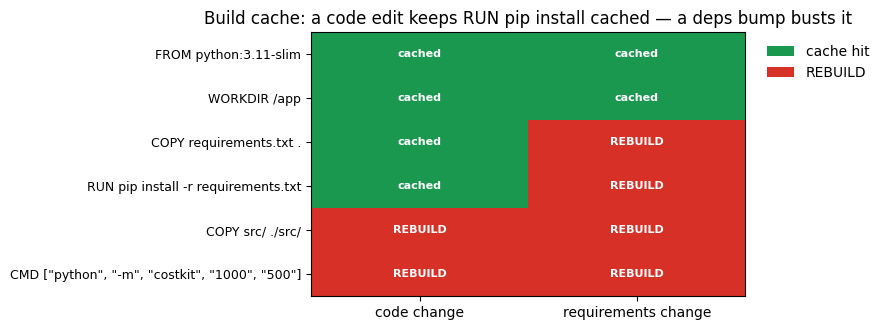

In [12]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# Reuse the Part 2 layer builder + cache replay for two different edits to the same image.
after_reqs = build_layers(INSTRUCTIONS, {**context, "requirements.txt": "pandas==3.1\n"})
cols = {"code change":         replay_cache(base_layers, layers_after_code),
        "requirements change": replay_cache(base_layers, after_reqs)}
labels = [r["instruction"] for r in base_layers]
grid = [[1 if c[i]["status"] == "REBUILD" else 0 for c in cols.values()]
        for i in range(len(labels))]

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.imshow(grid, cmap=ListedColormap(["#1a9850", "#d73027"]), vmin=-0.5, vmax=1.5, aspect="auto")
for y, row in enumerate(grid):                       # in-cell labels so meaning never rests on colour alone
    for x, v in enumerate(row):
        ax.text(x, y, "REBUILD" if v else "cached", ha="center", va="center",
                color="white", fontsize=8, fontweight="bold")
ax.set_xticks(range(len(cols)), list(cols))
ax.set_yticks(range(len(labels)), labels, fontsize=9)
ax.set_title("Build cache: a code edit keeps RUN pip install cached — a deps bump busts it")
ax.legend(handles=[Patch(facecolor="#1a9850", label="cache hit"),
                   Patch(facecolor="#d73027", label="REBUILD")],
          bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

## Part 3 · CI, simulated — *rebuild & test on every change*

Promise #3. **Continuous Integration** is the robot that runs on every push: it lints, tests, and builds your project so broken code never reaches production. On GitHub it's a **workflow** — a YAML file describing **jobs**, each with **steps**, wired together by `needs` dependencies.

`lab02_ci_pipeline_github_actions.ipynb` writes and runs a real workflow. Here we model the same structure as a Python dict, schedule it, and actually run a lint + a test locally — no GitHub required.

### 10. A workflow is a dict of jobs

A GitHub Actions workflow maps almost one-to-one onto a Python dict. `on` lists the triggers; `jobs` maps a name to its `needs` (which jobs must finish first) and its `steps`.

In [13]:
workflow = {
    "name": "ci",
    "on": ["push", "pull_request"],
    "jobs": {
        "lint":   {"needs": [],                "steps": ["ruff check ."]},
        "test":   {"needs": ["lint"],          "steps": ["pytest -q"]},
        "build":  {"needs": ["lint"],          "steps": ["docker build -t app ."]},
        "deploy": {"needs": ["test", "build"], "steps": ["./deploy.sh"]},
    },
}
jobs = workflow["jobs"]
for name, spec in jobs.items():
    needs = ", ".join(spec["needs"]) or "—"
    print(f"{name:8} needs: {needs:14} steps: {spec['steps']}")

lint     needs: —              steps: ['ruff check .']
test     needs: lint           steps: ['pytest -q']
build    needs: lint           steps: ['docker build -t app .']
deploy   needs: test, build    steps: ['./deploy.sh']


### 11. Topological sort → execution waves

`needs` defines a dependency graph. The runner has to turn it into an order: jobs with no unmet dependencies run **now** (in parallel), then jobs whose dependencies just finished, and so on. That's a **topological sort**, and grouping each round gives **waves** — the sets of jobs that run concurrently.

This is Kahn's algorithm: repeatedly take every job whose dependencies are all done, run them as one wave, mark them done, repeat. If a round finds nothing ready but jobs remain, there's a **cycle**.

In [14]:
def plan_waves(jobs):
    '''Group jobs into parallel waves that respect their `needs` (Kahn's algo).'''
    pending = {name: set(spec.get("needs", [])) for name, spec in jobs.items()}
    waves, done = [], set()
    while pending:
        ready = sorted(n for n, deps in pending.items() if deps <= done)
        if not ready:
            raise ValueError(f"cycle or missing dependency among {sorted(pending)}")
        waves.append(ready)
        done |= set(ready)
        for n in ready:
            del pending[n]
    return waves

waves = plan_waves(jobs)
for i, wave in enumerate(waves, 1):
    print(f"wave {i}: {wave}   (run in parallel)")

wave 1: ['lint']   (run in parallel)
wave 2: ['build', 'test']   (run in parallel)
wave 3: ['deploy']   (run in parallel)


> ⚠️ **A missing `needs` is a silent disaster.** Drop the `needs` from `deploy` and it lands in **wave 1** — deploying *before* `test` and `build` have even started. The dependency graph is the only thing standing between "tests gate production" and "we shipped a broken build to users in parallel with testing it." Wire `needs` deliberately.

### 12. Running the steps

A wave plan is just a schedule; CI still has to *run* something. We build a throwaway repo in a temp dir, then run two real steps as subprocesses — a **lint** (a stdlib `py_compile` syntax check) and a **test** (`pytest`) — exactly as a CI runner shells out to them. Results go into a table.

In [15]:
import os
import subprocess
import sys
import tempfile

def make_repo():
    '''A minimal repo: one module + one passing pytest test.'''
    repo = Path(tempfile.mkdtemp(prefix="ci_repo_"))
    (repo / "calc.py").write_text("def add(a, b):\n    return a + b\n")
    (repo / "test_calc.py").write_text(
        "from calc import add\n\n\ndef test_add():\n    assert add(2, 3) == 5\n"
    )
    return repo

def run_step(job, cmd, cwd):
    '''Run one CI step as a subprocess; capture pass/fail (never raises).'''
    env = {**os.environ, "PYTHONPATH": str(cwd)}
    try:
        proc = subprocess.run(cmd, cwd=str(cwd), env=env,
                              capture_output=True, text=True, timeout=90)
        return {"job": job, "command": " ".join(cmd[-2:]),
                "exit": proc.returncode, "passed": proc.returncode == 0}
    except Exception as exc:                           # pragma: no cover
        return {"job": job, "command": " ".join(cmd[-2:]),
                "exit": "err", "passed": False, "note": repr(exc)[:40]}

repo = make_repo()
results = [
    run_step("lint", [sys.executable, "-m", "py_compile", "calc.py"], repo),
    run_step("test", [sys.executable, "-m", "pytest", "-q"], repo),
]

import pandas as pd
results_df = pd.DataFrame(results)
all_green = bool(results_df["passed"].all())
print("pipeline:", "✅ all green — safe to deploy" if all_green else "❌ blocked")
results_df

pipeline: ✅ all green — safe to deploy


,job,command,exit,passed
0,lint,py_compile calc.py,0,True
1,test,pytest -q,0,True


> 🔬 **This is CI in one sentence.** *On every change, run the same commands you'd run by hand — in a clean, reproducible environment — and gate the next step on their exit codes.* The container from Part 2 *is* that clean environment; the waves from section 11 are the order; these subprocess steps are the work. Real GitHub Actions adds hosted runners, caching, secrets, and a nice UI — but the core is exactly this: **fresh checkout → run steps → non-zero exit fails the build.**

---

### ✋ Quick exercise (~2 min) — Add jobs and re-plan the waves

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Extend the pipeline: add a `docs` job that **needs nothing** and a `notify` job that **needs `deploy`**. Recompute the waves with `plan_waves(...)` and predict where each new job lands *before* you run it.

In [16]:
# ✍️ Your turn 👇
# Build the two new jobs, then merge them with the existing `jobs` dict.
extra_jobs = {}   # <- add "docs" (needs nothing) and "notify" (needs "deploy")
# plan = plan_waves({**jobs, **extra_jobs})
# for i, wave in enumerate(plan, 1):
#     print(f"wave {i}: {wave}")

<details>
<summary>✅ <b>Solution</b></summary>

```python
extra_jobs = {
    "docs":   {"needs": [],         "steps": ["mkdocs build"]},
    "notify": {"needs": ["deploy"], "steps": ["curl -X POST $SLACK_WEBHOOK"]},
}
plan = plan_waves({**jobs, **extra_jobs})
for i, wave in enumerate(plan, 1):
    print(f"wave {i}: {wave}")
```

`docs` needs nothing, so it joins `lint` in **wave 1**. `notify` needs `deploy`, so it can't run until `deploy` finishes — it becomes a new **final wave** on its own. Adding a job never reshuffles the others; the graph just grows.
</details>

## 🧪 Practice exercises

Five exercises across the three promises. Try each before opening its solution.

### Exercise 1 — ⭐ A cron for "every 15 minutes, weekdays only"

Write the cron expression that fires **every 15 minutes past the hour, Monday–Friday**, and verify it fires at Monday 09:15 but not at minute 09:07 and not on Saturday.

In [17]:
# Your code here  👇

<details>
<summary>💡 <b>Solution</b></summary>

```python
expr = "*/15 * * * 1-5"   # every 15 min, any hour, any date, Mon–Fri (cron 1-5)
assert matches(expr, dt.datetime(2026, 3, 2, 9, 15))       # Mon 09:15 -> yes
assert matches(expr, dt.datetime(2026, 3, 2, 9, 0))        # Mon 09:00 -> yes (0 % 15 == 0)
assert not matches(expr, dt.datetime(2026, 3, 2, 9, 7))    # minute 7  -> no
assert not matches(expr, dt.datetime(2026, 3, 7, 9, 15))   # Saturday  -> no
print("ok:", expr)
```

`*/15` matches minutes where `minute % 15 == 0` (0, 15, 30, 45); `1-5` is the weekday range (cron counts Sunday as 0). Combine step + range and you've described a genuinely common production schedule in five tokens.
</details>

### Exercise 2 — ⭐⭐ Retry with jitter

Copy the `retry` decorator and add **jitter**: instead of sleeping exactly `delay`, sleep a *random* amount in `[0, delay]`. Seed a `random.Random` for reproducibility. This is what stops a thousand clients from retrying in lockstep.

In [18]:
# Your code here  👇

<details>
<summary>💡 <b>Solution</b></summary>

```python
import functools, random

def retry_jitter(attempts=3, base_delay=0.01, backoff=2.0, seed=0):
    rng = random.Random(seed)
    def decorator(func):
        @functools.wraps(func)
        def wrapper(*args, **kwargs):
            delay = base_delay
            for attempt in range(1, attempts + 1):
                try:
                    return func(*args, **kwargs)
                except Exception:
                    if attempt == attempts:
                        raise
                    time.sleep(rng.uniform(0, delay))   # jitter: sleep in [0, delay]
                    delay *= backoff
        return wrapper
    return decorator

n = {"i": 0}
@retry_jitter(attempts=5, base_delay=0.01)
def flaky():
    n["i"] += 1
    if n["i"] < 3:
        raise TimeoutError("blip")
    return "ok"

print(flaky(), "after", n["i"], "tries")
```

**Full jitter** (uniform in `[0, delay]`) decorrelates retry storms far better than a fixed backoff; the AWS "exponential backoff and jitter" article is the canonical reference. Seeding keeps the test deterministic.
</details>

### Exercise 3 — ⭐⭐ Reorder a Dockerfile for cacheability

Given this bad Dockerfile, **reorder** it so a code-only change keeps `RUN pip install` cached, and prove it by comparing rebuilt-layer counts before and after your fix.

```
FROM python:3.11-slim
WORKDIR /app
COPY . .
RUN pip install -r requirements.txt
CMD ["python", "-m", "app"]
```

In [19]:
# Your code here  👇

<details>
<summary>💡 <b>Solution</b></summary>

```python
GOOD = '''
FROM python:3.11-slim
WORKDIR /app
COPY requirements.txt .
RUN pip install -r requirements.txt
COPY src/ ./src/
CMD ["python", "-m", "app"]
'''
good_ins = parse_dockerfile(GOOD)
base = build_layers(good_ins, context)
after = build_layers(good_ins, ctx_code_change)          # same code-only edit
rebuilt = sum(r["status"] == "REBUILD" for r in replay_cache(base, after))
print(f"reordered Dockerfile: {rebuilt} layers rebuild on a code change (was 3)")
assert rebuilt == 2
```

The fix is one idea: split the single `COPY . .` into `COPY requirements.txt .` (rarely changes) **before** `RUN pip install`, and `COPY src/ ./src/` (changes constantly) **after** it. Now a code edit invalidates only the code layer and the `CMD`, leaving the slow install cached.
</details>

### Exercise 4 — ⭐⭐ Detect a dependency cycle

Feed `plan_waves` a workflow where `a` needs `b` and `b` needs `a`. Confirm it raises `ValueError`, then break the cycle and confirm it plans cleanly.

In [20]:
# Your code here  👇

<details>
<summary>💡 <b>Solution</b></summary>

```python
cyclic = {"a": {"needs": ["b"]}, "b": {"needs": ["a"]}}
try:
    plan_waves(cyclic)
    print("no error?!")
except ValueError as e:
    print("caught cycle:", e)

fixed = {"a": {"needs": []}, "b": {"needs": ["a"]}}       # break one edge
print("fixed plan:", plan_waves(fixed))                  # [['a'], ['b']]
```

Kahn's algorithm detects a cycle by a **stall**: if a round finds no job whose dependencies are all done, yet jobs remain, the remaining jobs must depend on each other. Real CI validators reject cyclic `needs` the same way — before running anything.
</details>

### Exercise 5 — ⭐⭐ Debug me 🐞

The cache check below is meant to reproduce section 8, but it's **broken**: it compares each layer only to the same position and forgets the *cascade*. When you change an **early** layer (a dependency), the later `RUN pip install` layer has the same instruction text, so its independent hash matches — and the buggy check wrongly calls it a **cache hit**. The assertion catches the lie and raises. Find and fix the bug.

In [21]:
# 🐞 Buggy: a cache check that ignores whether an EARLIER layer changed.
def replay_cache_buggy(old_layers, new_layers):
    rows = []
    for i, layer in enumerate(new_layers):
        changed = i >= len(old_layers) or layer["hash"] != old_layers[i]["hash"]
        rows.append({
            "instruction": layer["instruction"],
            "status": "REBUILD" if changed else "cache hit",   # no cascade latch!
        })
    return rows

# Change a dependency (an early layer). pip install MUST re-run.
dep_ctx = dict(context)
dep_ctx["requirements.txt"] = "pandas==9.9\n"
dep_layers = build_layers(INSTRUCTIONS, dep_ctx)

buggy = replay_cache_buggy(base_layers, dep_layers)
rebuilt = {r["instruction"] for r in buggy if r["status"] == "REBUILD"}
assert "RUN pip install -r requirements.txt" in rebuilt, (
    "pip install must re-run when requirements change — the buggy cache skipped it!"
)
print("pip install correctly rebuilt")

AssertionError: pip install must re-run when requirements change — the buggy cache skipped it!

<details>
<summary>💡 <b>Solution</b></summary>

The bug is the **missing cascade latch**. A per-position hash comparison is not enough, because our layer hashes are independent: when `requirements.txt` changes, only the `COPY requirements.txt` hash changes; the later `RUN pip install` text is identical, so its hash matches and the buggy check keeps it "cached" — even though Docker (and reality) must re-run the install. Once *any* layer rebuilds, every layer after it must too.

```python
def replay_cache_fixed(old_layers, new_layers):
    rows, rebuilding = [], False
    for i, layer in enumerate(new_layers):
        changed = i >= len(old_layers) or layer["hash"] != old_layers[i]["hash"]
        if changed:
            rebuilding = True                # ← the fix: latch stays on to the end
        rows.append({
            "instruction": layer["instruction"],
            "status": "REBUILD" if rebuilding else "cache hit",
        })
    return rows

fixed = replay_cache_fixed(base_layers, dep_layers)
rebuilt = {r["instruction"] for r in fixed if r["status"] == "REBUILD"}
assert "RUN pip install -r requirements.txt" in rebuilt   # now passes
print("fixed:", sum(r["status"] == "REBUILD" for r in fixed), "layers rebuild")
```

**Lesson.** A cache is only correct if invalidation **propagates**. Comparing each item independently is the classic caching bug — it's why real build systems chain a layer's identity onto its parent's, so a change downstream is impossible to miss.
</details>

## 🧠 Stretch exercises

Two harder, applied problems that compose the pieces you built. Try them before opening the solution.

### Stretch exercise C — ⭐⭐⭐ An end-to-end "ship it" gate

Wire all three promises into one function `ship(context_new)` that simulates a deploy triggered by a change:

1. **Build** — `replay_cache` the layers for `context_new` against `base_layers`; report how many rebuild.
2. **Test** — run the CI steps (`run_step` lint + test) in a fresh `make_repo()`.
3. **Gate** — only "deploy" if *every* step passed; otherwise block.

Return a dict summarising `{rebuilt, tests_passed, deployed}`. Prove it deploys on a green build.

In [22]:
# Your code here  👇
def ship(context_new):
    ...
    return {}

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def ship(context_new):
    # 1. BUILD: which layers rebuild for this change?
    new_layers = build_layers(INSTRUCTIONS, context_new)
    rebuilt = sum(r["status"] == "REBUILD" for r in replay_cache(base_layers, new_layers))

    # 2. TEST: run the CI steps in a clean repo.
    repo = make_repo()
    steps = [
        run_step("lint", [sys.executable, "-m", "py_compile", "calc.py"], repo),
        run_step("test", [sys.executable, "-m", "pytest", "-q"], repo),
    ]
    tests_passed = all(s["passed"] for s in steps)

    # 3. GATE: deploy only if the build is green.
    deployed = tests_passed
    return {"rebuilt": rebuilt, "tests_passed": tests_passed, "deployed": deployed}

result = ship(ctx_code_change)
print(result)
assert result["deployed"] is True and result["tests_passed"] is True
```

**Reasoning.** This is the entire shape of a deployment pipeline in fifteen lines, and it shows how the three promises *compose*: the container gives you a reproducible build (Part 2), CI gives you a pass/fail signal (Part 3), and the **gate** — `deployed = tests_passed` — is the one line that makes tests actually mean something. A pipeline without that gate is just theatre: it runs the tests and ships regardless. The value isn't in running tests; it's in *refusing to deploy when they fail*.
</details>

### Stretch exercise D — ⭐⭐⭐ A catch-up (backfill) scheduler

A scheduler that was offline overnight must **catch up** on the ticks it missed. Write `backfill(cron_expr, last_run, now, job)` that finds every minute strictly after `last_run` up to and including `now` where `matches(cron_expr, minute)` is true, and runs `job` on each — **idempotently**, so re-running the same backfill does no extra work. Return the list of timestamps it fired.

In [23]:
# Your code here  👇
def backfill(cron_expr, last_run, now, job):
    ...
    return []

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def backfill(cron_expr, last_run, now, job):
    fired, cursor = [], last_run + dt.timedelta(minutes=1)
    while cursor <= now:
        if matches(cron_expr, cursor):
            job(cursor)                 # job itself is idempotent (see section 4)
            fired.append(cursor)
        cursor += dt.timedelta(minutes=1)
    return fired

done = {}                               # our idempotent "already ran?" store
def hourly_job(when):
    done.setdefault(when, 0)
    done[when] += 1                     # idempotent guard would no-op a repeat

# We were down from 22:00 to 02:00; catch up the top-of-hour runs we missed.
missed = backfill("0 * * * *",
                  dt.datetime(2026, 3, 2, 22, 0),
                  dt.datetime(2026, 3, 3, 2, 0),
                  hourly_job)
print("backfilled:", [f"{t:%H:%M}" for t in missed])   # 23:00, 00:00, 01:00, 02:00
assert len(missed) == 4
```

**Reasoning.** Backfill is where **idempotency stops being optional**. A catch-up run deliberately re-fires jobs for past timestamps, and an operator who runs the backfill twice (because they weren't sure it finished) must not get double writes — so the job *must* be safe to repeat, exactly the property from section 4. Note the design: the scheduler decides *which* moments to replay (walk the minutes, ask `matches`), while the *job* owns "have I already done this one?" That separation — scheduler picks the ticks, job guarantees idempotency — is how production backfills stay correct.
</details>

## 🧠 Key takeaways

Shipping is three promises, and you built a working model of each:

1. **Run it on a schedule you trust.** A scheduler is a clock + a `matches(cron, when)` rule + a job. Separating *when* from *advance the clock* makes schedules testable — replay a year of ticks in milliseconds.
2. **Idempotency is non-negotiable.** Jobs *will* run twice (retries, backfills, DST, double workers). Design for the second run first: a natural key + an "already done?" guard, or a database upsert.
3. **Retry transient failures with capped, jittered backoff** — and never retry a `400`.
4. **A container is reproducibility.** A Dockerfile is a list of instructions hashed into cached layers; the same image runs identically everywhere.
5. **Order the Dockerfile requirements-first, code-last.** Least-likely-to-change instructions at the top keeps the slow `pip install` cached across code edits.
6. **A cache is only correct if invalidation cascades.** Once one layer rebuilds, every layer after it must too.
7. **CI is a dependency graph.** Jobs-with-`needs` topologically sort into parallel waves; a missing `needs` can deploy before tests run.
8. **CI's whole point is the gate.** Run the same commands on every change in a clean environment, and *refuse to proceed* on a non-zero exit.

> 🧭 **The mental model, once more.** Ship = schedule you trust + package that runs the same everywhere + rebuild-and-test on every change. Cron matcher, layer cache, CI graph — three small simulations, one production discipline. The canonical notebook and the `14_cicd/` labs swap each simulation for the real daemon, real Docker, and a real GitHub Actions runner; the ideas you just coded don't change.

## ✅ Self-assessment

- [ ] Write and match a five-field cron expression with `matches(cron_expr, when)`
- [ ] Explain why a scheduled job must be idempotent, and add an "already done?" guard
- [ ] Write a retry-with-backoff decorator and say when *not* to retry
- [ ] Parse a Dockerfile into instructions and hash them into layers
- [ ] Predict which layers rebuild after a deps change vs a code change
- [ ] Order a Dockerfile "requirements first, code last" and justify it
- [ ] Model a CI workflow as jobs-with-`needs` and sort it into execution waves
- [ ] Explain the CI gate: why a non-zero exit must block the next step

## 🚀 Next step

Continue with **Notebook 21 (fast track) — Capstone**, where you bring the whole track together into one project.

For the full depth this notebook condensed, open the canonical **Module 13** — [`13_production/46_scheduling_orchestration.ipynb`](../13_production/46_scheduling_orchestration.ipynb) — and the **CI/CD mini-book** in [`14_cicd/`](../14_cicd/), especially its hands-on labs [`lab01_docker_and_compose.ipynb`](../14_cicd/lab01_docker_and_compose.ipynb) and [`lab02_ci_pipeline_github_actions.ipynb`](../14_cicd/lab02_ci_pipeline_github_actions.ipynb), which build and run the real thing.